In [2]:
import pandas as pd
import numpy as np

In [12]:
TRAIN = "../data/train.csv"
TRAIN_SOUNDSCAPES_LABELS = "../data/train_soundscapes_labels.csv"
TAXONOMY = "../data/taxonomy.csv"
SAMPLE_SUBMISSION = "../data/sample_submission.csv"

In [13]:
train = pd.read_csv(TRAIN)
train_soundscapes_labels = pd.read_csv(TRAIN_SOUNDSCAPES_LABELS)
taxonomy = pd.read_csv(TAXONOMY)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION)

In [15]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  str    
 1   secondary_labels  35549 non-null  str    
 2   type              35549 non-null  str    
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  str    
 6   common_name       35549 non-null  str    
 7   class_name        35549 non-null  str    
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  str    
 10  license           35549 non-null  str    
 11  rating            35549 non-null  float64
 12  url               35549 non-null  str    
 13  filename          35549 non-null  str    
 14  collection        35549 non-null  str    
dtypes: float64(3), int64(1), str(11)
memory usage: 4.1 MB


In [17]:
train_soundscapes_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   filename       1478 non-null   str  
 1   start          1478 non-null   str  
 2   end            1478 non-null   str  
 3   primary_label  1478 non-null   str  
dtypes: str(4)
memory usage: 46.3 KB


In [18]:
taxonomy.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   primary_label    234 non-null    str  
 1   inat_taxon_id    234 non-null    int64
 2   scientific_name  234 non-null    str  
 3   common_name      234 non-null    str  
 4   class_name       234 non-null    str  
dtypes: int64(1), str(4)
memory usage: 9.3 KB


In [19]:
sample_submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Columns: 235 entries, row_id to yeofly1
dtypes: float64(234), str(1)
memory usage: 5.6 KB


In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

from IPython.display import Audio

def plot_species_audio(data_dir, train_df, species_code, n_samples=1, rating=5.0):
    mask = (train_df['primary_label'] == species_code) & (train_df['rating'] == rating)
    species_samples = train_df[mask].head(n_samples)

    if species_samples.empty:
        print(f"Warning: No samples rated 5.0 for {species_code}. Searching for the best available...")
        species_samples = train_df[train_df['primary_label'] == species_code].sort_values('rating', ascending=False).head(n_samples)

    if species_samples.empty:
        print(f"Error: No sample found for the species: {species_code}")
        return

    for idx, row in species_samples.iterrows():
        file_path = os.path.join(data_dir, 'train_audio', row['filename'])
        
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        print(f"--- Viewing: {species_code} (Rating: {row['rating']}) ---")

        y, sr = librosa.load(file_path, sr=32000)
        
        fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        
        # Wave
        librosa.display.waveshow(y, sr=sr, ax=ax[0], color='blue')
        ax[0].set_title(f'Waveform: {species_code} (Rating: {row["rating"]})')
        ax[0].set_ylabel('Amplitude')

        # Mel
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=16000)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', 
                                      fmax=16000, ax=ax[1])
        ax[1].set_title(f'Mel-Spectrogram: {species_code}')
        fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
        
        plt.tight_layout()
        plt.show()

Species selected for testing (Rating 5.0): 1595929
--- Viewing: 1595929 (Rating: 5.0) ---


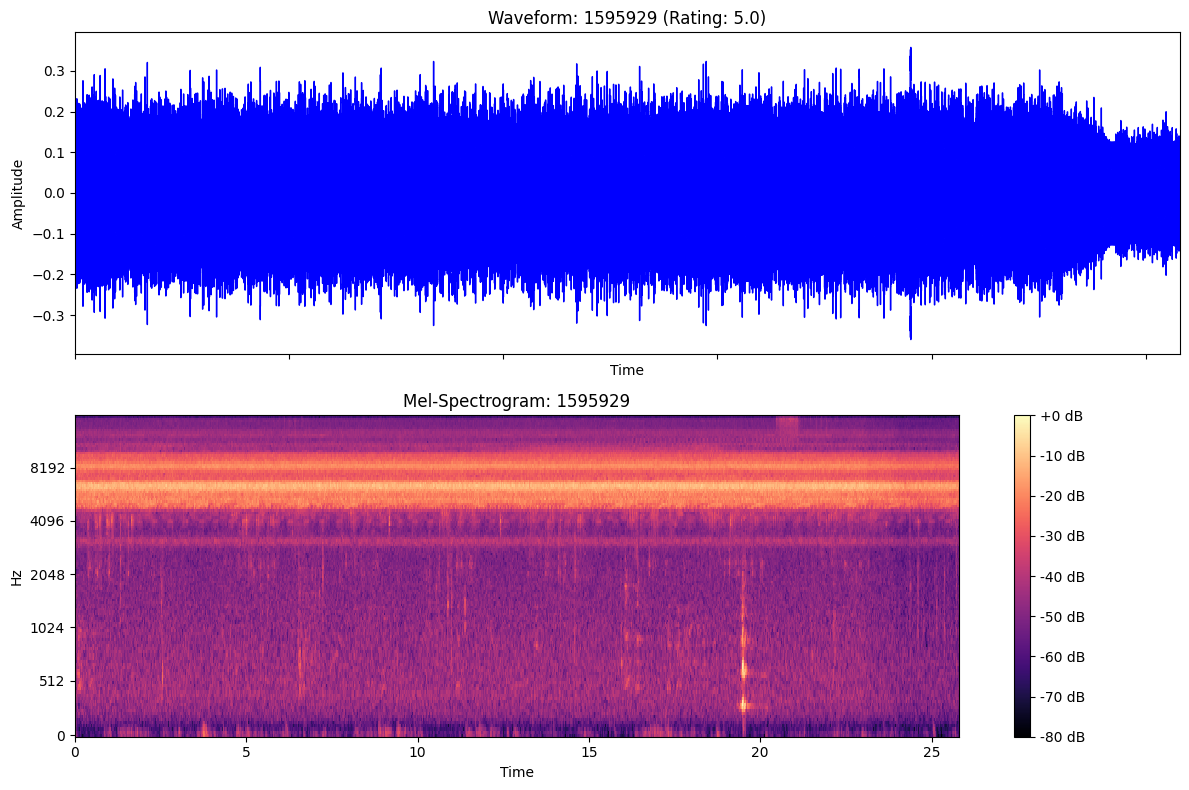

In [59]:
DATA_DIR = "../data"
train_metadata = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

best_rated_samples = train_metadata[train_metadata['rating'] == 5.0]

if not best_rated_samples.empty:
    sample_species = best_rated_samples['primary_label'].iloc[0]
    print(f"Species selected for testing (Rating 5.0): {sample_species}")
else:
    sample_species = train_metadata['primary_label'].iloc[0]
    print(f"No samples with a score of 5.0 were found in the dataset. Testing with: {sample_species}")
    
plot_species_audio(DATA_DIR, train_metadata, sample_species)

Species selected for testing (Rating 5.0): 41970
--- Viewing: 41970 (Rating: 5.0) ---


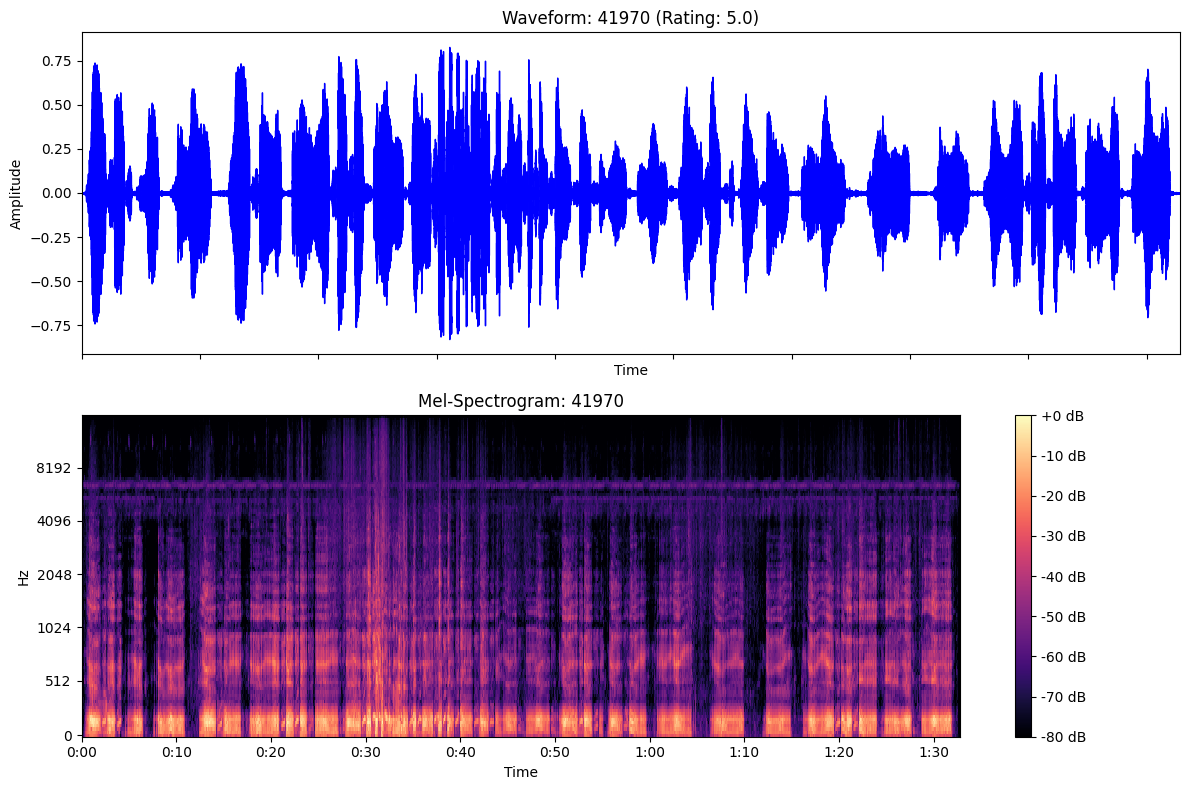

In [60]:
DATA_DIR = "../data"
train_metadata = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

best_rated_samples = train_metadata[train_metadata['rating'] == 1.0]

if not best_rated_samples.empty:
    sample_species = best_rated_samples['primary_label'].iloc[0]
    print(f"Species selected for testing (Rating 5.0): {sample_species}")
else:
    sample_species = train_metadata['primary_label'].iloc[0]
    print(f"No samples with a score of 5.0 were found in the dataset. Testing with: {sample_species}")
    
plot_species_audio(DATA_DIR, train_metadata, sample_species)

Species selected for comparison: purjay1

>>> DISPLAYING MAXIMUM QUALITY (5.0)
--- Viewing: purjay1 (Rating: 5.0) ---


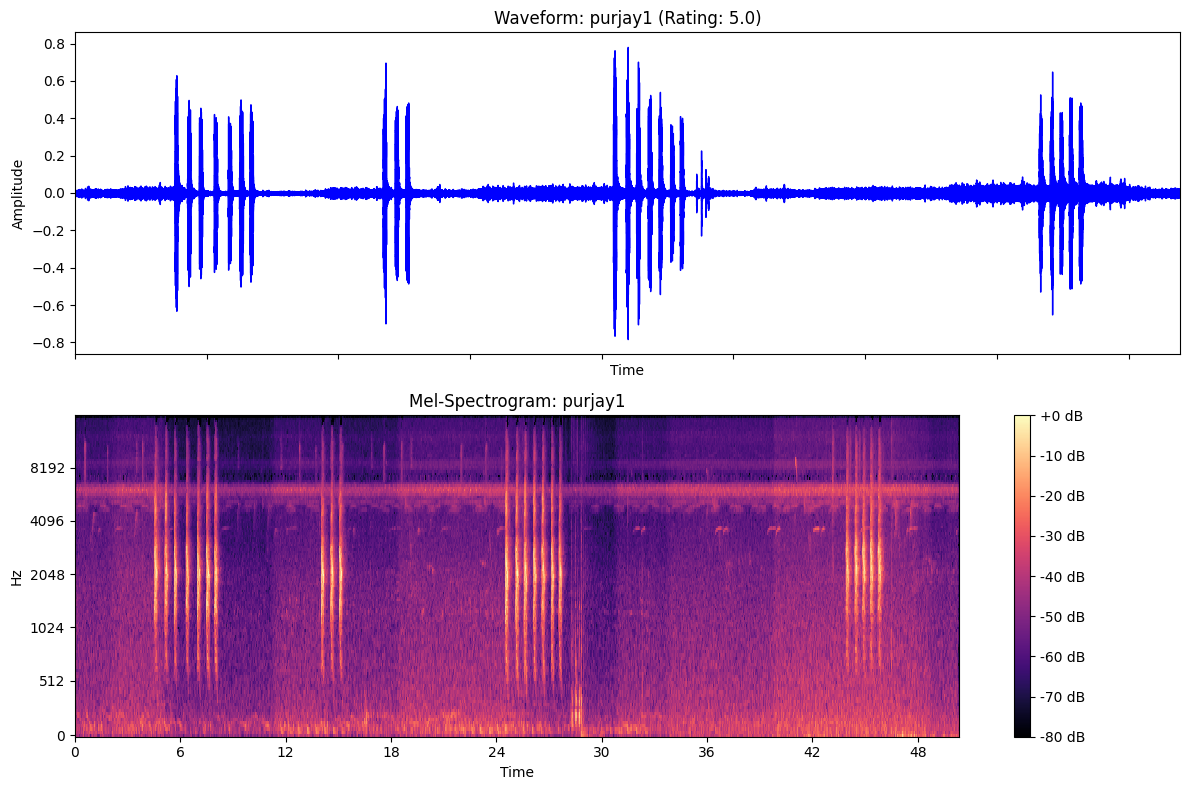


>>> DISPLAYING LOW QUALITY (<= 2.0)
--- Viewing: purjay1 (Rating: 0.0) ---


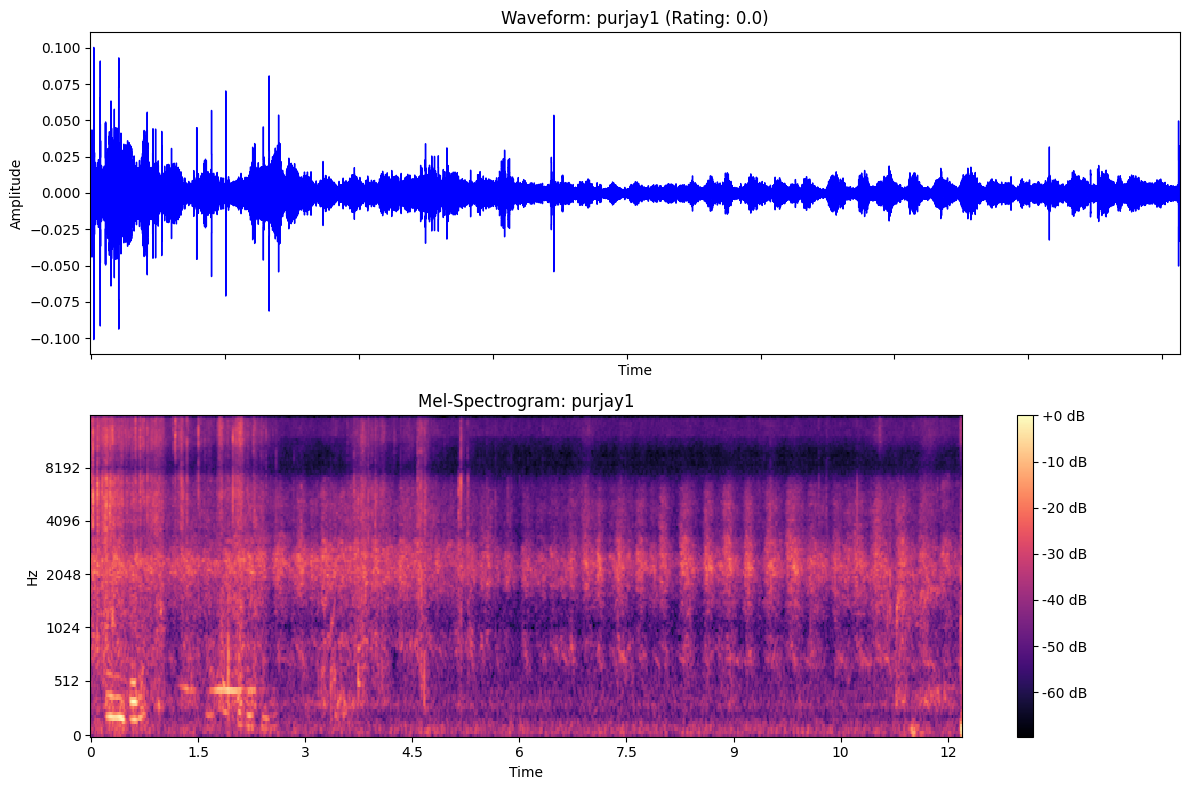

In [65]:
DATA_DIR = "../data"
train_metadata = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))

species_with_5 = set(train_metadata[train_metadata['rating'] == 5.0]['primary_label'])
species_with_low = set(train_metadata[train_metadata['rating'] <= 2.0]['primary_label'])

common_species = list(species_with_5.intersection(species_with_low))

if common_species:
    target = common_species[0]
    print(f"Species selected for comparison: {target}")
    
    print("\n>>> DISPLAYING MAXIMUM QUALITY (5.0)")
    plot_species_audio(DATA_DIR, train_metadata, target, rating=5.0)
    
    print("\n>>> DISPLAYING LOW QUALITY (<= 2.0)")
    low_rating = train_metadata[train_metadata['primary_label'] == target]['rating'].min()
    plot_species_audio(DATA_DIR, train_metadata, target, rating=low_rating)
else:
    sample_species = train_metadata['primary_label'].iloc[0]
    plot_species_audio(DATA_DIR, train_metadata, sample_species)